<a href="https://colab.research.google.com/github/boganast2206/stat_pract/blob/main/Homework7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
%matplotlib inline

all_data = pd.read_csv('/content/datasets/forest_dataset.csv')
print("Размер датасета:", all_data.shape)
print("\nПервые несколько строк:")
all_data.head()

Размер датасета: (10000, 55)

Первые несколько строк:


,0,1,2,3,4,5,6,7,8,9,...,45,46,47,48,49,50,51,52,53,54
0,2683,333,35,30,26,2743,121,173,179,6572,...,0,0,0,0,0,0,0,0,0,2
1,2915,90,8,216,11,4433,232,228,129,4019,...,0,0,0,0,0,0,0,0,0,1
2,2941,162,7,698,76,2783,227,242,148,1784,...,0,0,0,0,0,0,0,0,0,2
3,3096,60,17,170,3,3303,231,202,99,5370,...,0,0,0,0,0,0,0,0,0,1
4,2999,66,8,488,37,1532,228,225,131,2290,...,0,0,0,0,0,0,0,0,0,2


Лучшие параметры: {'metric': 'manhattan', 'n_neighbors': 4, 'weights': 'distance'}
Точность на тесте с оптимальными параметрами: 0.7845


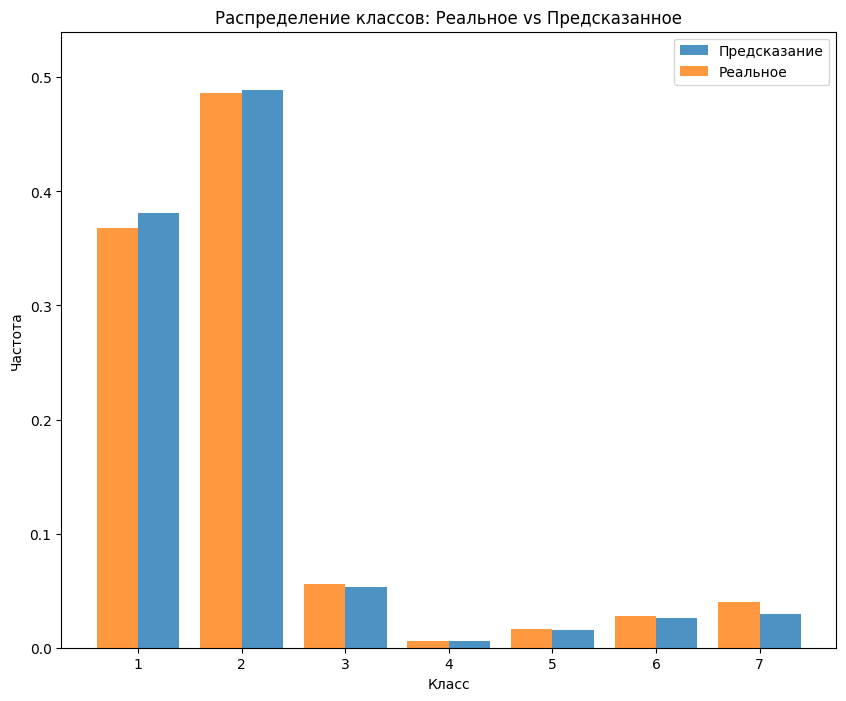


Сравнение моделей


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Точность KNN: 0.7845
Точность логистической регрессии: 0.6840

Преимущества и недостатки метода K ближайших соседей 

Преимущества:
1. Простой и интуитивно понятный алгоритм
2. Отсутствие этапа обучения - просто хранит все данные
3. Может работать с многоклассовой классификацией
4. Хорошо работает с нелинейными разделяющими границами
5. Эффективен при достаточно большом объеме данных

Недостатки:
1. Вычислительно затратен при предсказаниях
2. Чувствителен к неинформативным признакам и масштабированию
3. Требует много памяти (хранит все обучающие данные)


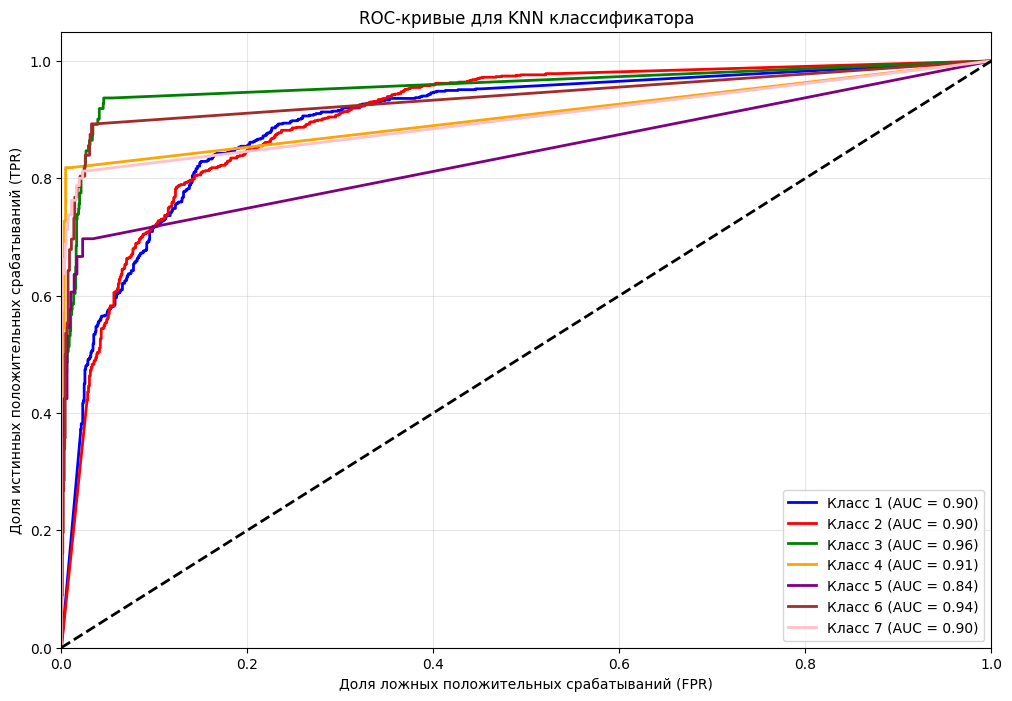

Площадь под кривой ROC: 0.9041


In [11]:
labels = all_data[all_data.columns[-1]].values
feature_matrix = all_data[all_data.columns[:-1]].values


train_feature_matrix, test_feature_matrix, train_labels, test_labels = train_test_split(
    feature_matrix, labels, test_size=0.2, random_state=42)

clf = KNeighborsClassifier()

params = {
    'n_neighbors': range(1, 11),
    'metric': ['manhattan', 'euclidean'],
    'weights': ['uniform', 'distance']
}

clf_grid = GridSearchCV(clf, params, cv=5, scoring='accuracy', n_jobs=-1)
clf_grid.fit(train_feature_matrix, train_labels)

print("Лучшие параметры:", clf_grid.best_params_)


optimal_clf = KNeighborsClassifier(**clf_grid.best_params_)
optimal_clf.fit(train_feature_matrix, train_labels)

y_pred = optimal_clf.predict(test_feature_matrix)
accuracy = accuracy_score(test_labels, y_pred)
print("Точность на тесте с оптимальными параметрами: {:.4f}".format(accuracy))

pred_prob = optimal_clf.predict_proba(test_feature_matrix)

unique, freq = np.unique(test_labels, return_counts=True)
freq = list(map(lambda x: x / len(test_labels), freq))
pred_freq = pred_prob.mean(axis=0)

plt.figure(figsize=(10, 8))
plt.bar(range(1, 8), pred_freq, width=0.4, align="edge", label='Предсказание', alpha=0.8)
plt.bar(range(1, 8), freq, width=-0.4, align="edge", label='Реальное', alpha=0.8)
plt.ylim(0, 0.54)
plt.xlabel('Класс')
plt.ylabel('Частота')
plt.title('Распределение классов: Реальное vs Предсказанное')
plt.legend()
plt.show()

print("\nСравнение моделей")
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(train_feature_matrix, train_labels)
log_pred = log_reg.predict(test_feature_matrix)
log_accuracy = accuracy_score(test_labels, log_pred)

print("Точность KNN: {:.4f}".format(accuracy))
print("Точность логистической регрессии: {:.4f}".format(log_accuracy))


print("\nПреимущества и недостатки метода K ближайших соседей ")
print("\nПреимущества:")
print("1. Простой и интуитивно понятный алгоритм")
print("2. Отсутствие этапа обучения - просто хранит все данные")
print("3. Может работать с многоклассовой классификацией")
print("4. Хорошо работает с нелинейными разделяющими границами")
print("5. Эффективен при достаточно большом объеме данных")

print("\nНедостатки:")
print("1. Вычислительно затратен при предсказаниях")
print("2. Чувствителен к неинформативным признакам и масштабированию")
print("3. Требует много памяти (хранит все обучающие данные)")

test_labels_binarized = label_binarize(test_labels, classes=np.unique(labels))
n_classes = len(np.unique(labels))

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(test_labels_binarized[:, i], pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(12, 8))
colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink']
for i, color in enumerate(colors[:n_classes]):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='Класс {0} (AUC = {1:0.2f})'.format(i+1, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Доля ложных положительных срабатываний (FPR)')
plt.ylabel('Доля истинных положительных срабатываний (TPR)')
plt.title('ROC-кривые для KNN классификатора')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

average_auc = roc_auc_score(test_labels_binarized, pred_prob, average='weighted')
print("Площадь под кривой ROC: {:.4f}".format(average_auc))